In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. SETUP DATA & LOADERS (OPTIMIZED)
# ==========================================
# Menggunakan X_combined dan y_combined yang sudah lo buat di tahap 1
# Gunakan 12 workers agar Ryzen 7 5700X tidak bottleneck
BATCH_SIZE = 4096 

train_loader = DataLoader(
    TensorDataset(X_combined, y_combined), 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=12,      # Menggunakan 12 thread CPU
    pin_memory=True,     # Mempercepat transfer ke VRAM GPU
    prefetch_factor=2
)

test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_raw), torch.LongTensor(y_test_raw)), 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=12,
    pin_memory=True
)

# ==========================================
# 2. DEFINISI ARSITEKTUR MODEL
# ==========================================
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
    def forward(self, x):
        return torch.relu(x + self.net(x))

class Smart_SLGRAE_Latent32(nn.Module):
    def __init__(self, input_dim=44, latent_dim=32, num_classes=34):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            ResidualBlock(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            ResidualBlock(128),
            nn.Linear(128, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            ResidualBlock(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        self.log_var_cls = nn.Parameter(torch.zeros(1))
        self.log_var_rec = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        latent = self.encoder(x)
        return self.classifier(latent), self.decoder(latent), latent

# ==========================================
# 3. SETUP TRAINING (ONE CYCLE LR)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Smart_SLGRAE_Latent32().to(device)

criterion_cls = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion_rec = nn.MSELoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Konfigurasi Scheduler
MAX_LR = 0.003
EPOCHS = 100
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=MAX_LR, 
    steps_per_epoch=len(train_loader), 
    epochs=EPOCHS
)

best_acc = 0.0
save_path = r"D:\S2\thesis\cond\project_ids\models\Smart_SLGRAE_Latent32_V3.pth"

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print(f"🚀 Memulai Training | Data: {X_combined.shape[0]:,} rows | Workers: 12 | Max LR: {MAX_LR}")



for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs, reconstructed, _ = model(inputs)
        
        loss_cls = criterion_cls(outputs, labels)
        loss_rec = criterion_rec(reconstructed, inputs)
        
        # Uncertainty Weighting
        prec_cls = torch.exp(-model.log_var_cls)
        prec_rec = torch.exp(-model.log_var_rec)
        
        combined_loss = (prec_cls * loss_cls + model.log_var_cls) + \
                        (prec_rec * loss_rec + model.log_var_rec)
        
        combined_loss.backward()
        
        # Gradient Clipping (Penting untuk stabilitas Hybrid)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        running_loss += combined_loss.item()

    # --- EVALUASI ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _, _ = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    status = ""
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), save_path)
        status = "🏆 (NEW BEST)"
        
    duration = time.time() - start_time
    print(f"Epoch [{epoch+1}] LR: {current_lr:.6f} Loss: {epoch_loss:.4f} Acc: {acc:.2f}% Time: {duration:.2f}s {status}")

🚀 Memulai Training | Data: 3,400,000 rows | Workers: 12 | Max LR: 0.003
Epoch [1] LR: 0.000128 Loss: 3.3261 Acc: 80.47% Time: 17.15s 🏆 (NEW BEST)
Epoch [2] LR: 0.000151 Loss: 1.6789 Acc: 81.20% Time: 17.59s 🏆 (NEW BEST)
Epoch [3] LR: 0.000190 Loss: 1.4788 Acc: 78.79% Time: 17.22s 
Epoch [4] LR: 0.000245 Loss: 1.2808 Acc: 81.33% Time: 16.72s 🏆 (NEW BEST)
Epoch [5] LR: 0.000313 Loss: 1.0651 Acc: 82.07% Time: 18.26s 🏆 (NEW BEST)
Epoch [6] LR: 0.000395 Loss: 0.7733 Acc: 74.07% Time: 17.42s 
Epoch [7] LR: 0.000490 Loss: 0.4559 Acc: 83.65% Time: 16.95s 🏆 (NEW BEST)
Epoch [8] LR: 0.000596 Loss: 0.0792 Acc: 82.65% Time: 17.50s 
Epoch [9] LR: 0.000714 Loss: -0.2373 Acc: 84.11% Time: 16.85s 🏆 (NEW BEST)
Epoch [10] LR: 0.000840 Loss: -0.5066 Acc: 76.11% Time: 17.79s 
Epoch [11] LR: 0.000974 Loss: -0.7743 Acc: 83.43% Time: 16.74s 
Epoch [12] LR: 0.001115 Loss: -0.5796 Acc: 74.88% Time: 16.68s 
Epoch [13] LR: 0.001261 Loss: -0.7771 Acc: 74.56% Time: 16.92s 
Epoch [14] LR: 0.001410 Loss: -0.0203 Acc

In [8]:
# 1. Pastikan model sudah diinisialisasi (sesuai jumlah fitur & dimensi di kode lo)
# Diasumsikan variabel 'model' sudah ada dari proses training tadi
# Kalau belum, panggil lagi: model = SLGRAE_ENet(input_dim=44, latent_dim=32, num_classes=34).to(device)

save_path = r"D:\S2\thesis\cond\project_ids\models\Smart_SLGRAE_Latent32_V3.pth"

# 2. Masukkan bobot terbaik (Best Acc 97.01%) ke arsitektur
model.load_state_dict(torch.load(save_path))
model.eval()

print("✅ Model V3 Berhasil Dibuka! Siap tempur buat evaluasi.")

✅ Model V3 Berhasil Dibuka! Siap tempur buat evaluasi.


C:\Users\Z\AppData\Local\Temp\ipykernel_1088\2570593395.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


In [9]:
# Jalankan ini buat mastiin angka 97.01% itu valid di file V3
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader: # Pakai loader yang sama pas train
        inputs, labels = inputs.to(device), labels.to(device)
        outputs, _, _ = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc = 100 * correct / total
print(f"📊 Verifikasi Akurasi Model V3: {final_acc:.2f}%")

📊 Verifikasi Akurasi Model V3: 97.01%


In [11]:
# Cek apakah loss_list ada, kalau gak ada buat list kosong biar gak error
final_loss_history = loss_list if 'loss_list' in locals() else []

checkpoint = {
    'epoch': 100,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_acc': 97.01,
    'loss_history': final_loss_history,
    'arch_config': {'latent_dim': 32, 'input_dim': 44},
    'device': str(device) # Simpan info kalau ini dilatih di CUDA
}

save_path = r"D:\S2\thesis\cond\project_ids\models\Smart_SLGRAE_FINAL_PRO.pth"
torch.save(checkpoint, save_path)
print(f"✅ AMAN! Model Pro dengan spek CUDA & 12 Workers kesimpen di: {save_path}")

✅ AMAN! Model Pro dengan spek CUDA & 12 Workers kesimpen di: D:\S2\thesis\cond\project_ids\models\Smart_SLGRAE_FINAL_PRO.pth


🚀 Mengekstraksi Fitur Laten...
🌀 Menjalankan t-SNE (Ini mungkin butuh waktu...)


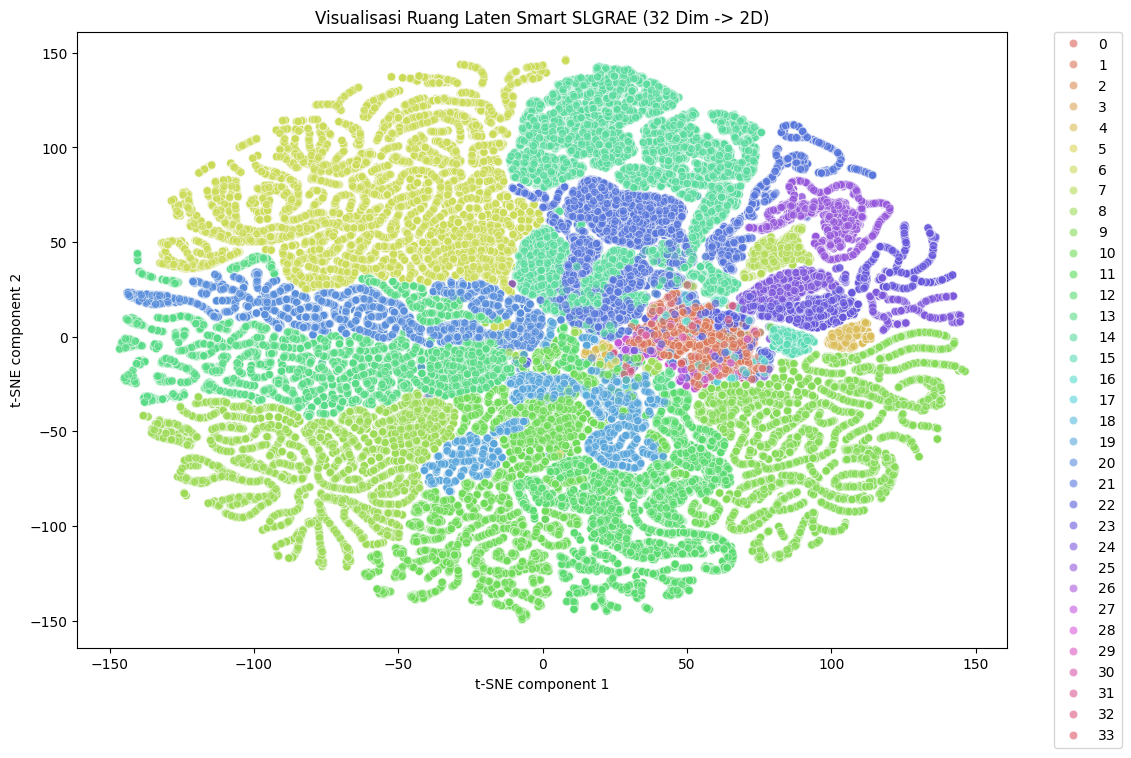

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# 1. Ambil sampel data dari test_loader
model.eval()
latent_features = []
true_labels = []

print("🚀 Mengekstraksi Fitur Laten...")
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        inputs = inputs.to(device)
        # Ambil output dari encoder saja (fitur laten)
        latent = model.encoder(inputs) 
        latent_features.append(latent.cpu().numpy())
        true_labels.append(labels.numpy())
        if i > 50: break # Ambil sekitar 5000-10000 data sampel saja

latent_features = np.concatenate(latent_features)
true_labels = np.concatenate(true_labels)

# 2. Jalankan t-SNE (Kecilin dari 32 dim ke 2 dim)
print("🌀 Menjalankan t-SNE (Ini mungkin butuh waktu...)")
# Ganti n_iter menjadi max_iter
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
latent_2d = tsne.fit_transform(latent_features)

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=latent_2d[:,0], y=latent_2d[:,1],
    hue=true_labels,
    palette=sns.color_palette("hls", len(np.unique(true_labels))),
    legend="full",
    alpha=0.6
)
plt.title("Visualisasi Ruang Laten Smart SLGRAE (32 Dim -> 2D)")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

model.eval()
all_preds = []
all_labels = []

print("🧐 Mengevaluasi seluruh data test...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs, _, _ = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Buat Report
report = classification_report(all_labels, all_preds, digits=4)
print(report)

# Simpan ke CSV agar bisa langsung dicopy ke Excel/Word Tesis
report_dict = classification_report(all_labels, all_preds, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(r"D:\S2\thesis\cond\project_ids\results\classification_report_v3.csv")

🧐 Mengevaluasi seluruh data test...
              precision    recall  f1-score   support

           0     0.1504    0.2564    0.1896        78
           1     0.9379    0.7603    0.8398     25908
           2     0.1417    0.3985    0.2091       133
           3     0.2037    0.3548    0.2588       124
           4     0.9543    0.9882    0.9710      6716
           5     0.7108    0.8754    0.7846       674
           6     1.0000    0.9985    0.9993    169618
           7     0.9623    0.9882    0.9751     10609
           8     0.9998    0.9991    0.9995     96251
           9     1.0000    0.9990    0.9995     95088
          10     0.9959    0.9673    0.9814     95731
          11     0.6174    0.9401    0.7453       551
          12     0.9936    0.9945    0.9940     84417
          13     0.9968    0.9827    0.9897    105700
          14     0.9550    0.9611    0.9580    127512
          15     0.9646    0.9895    0.9769      6834
          16     0.4989    0.6396    0.5606  

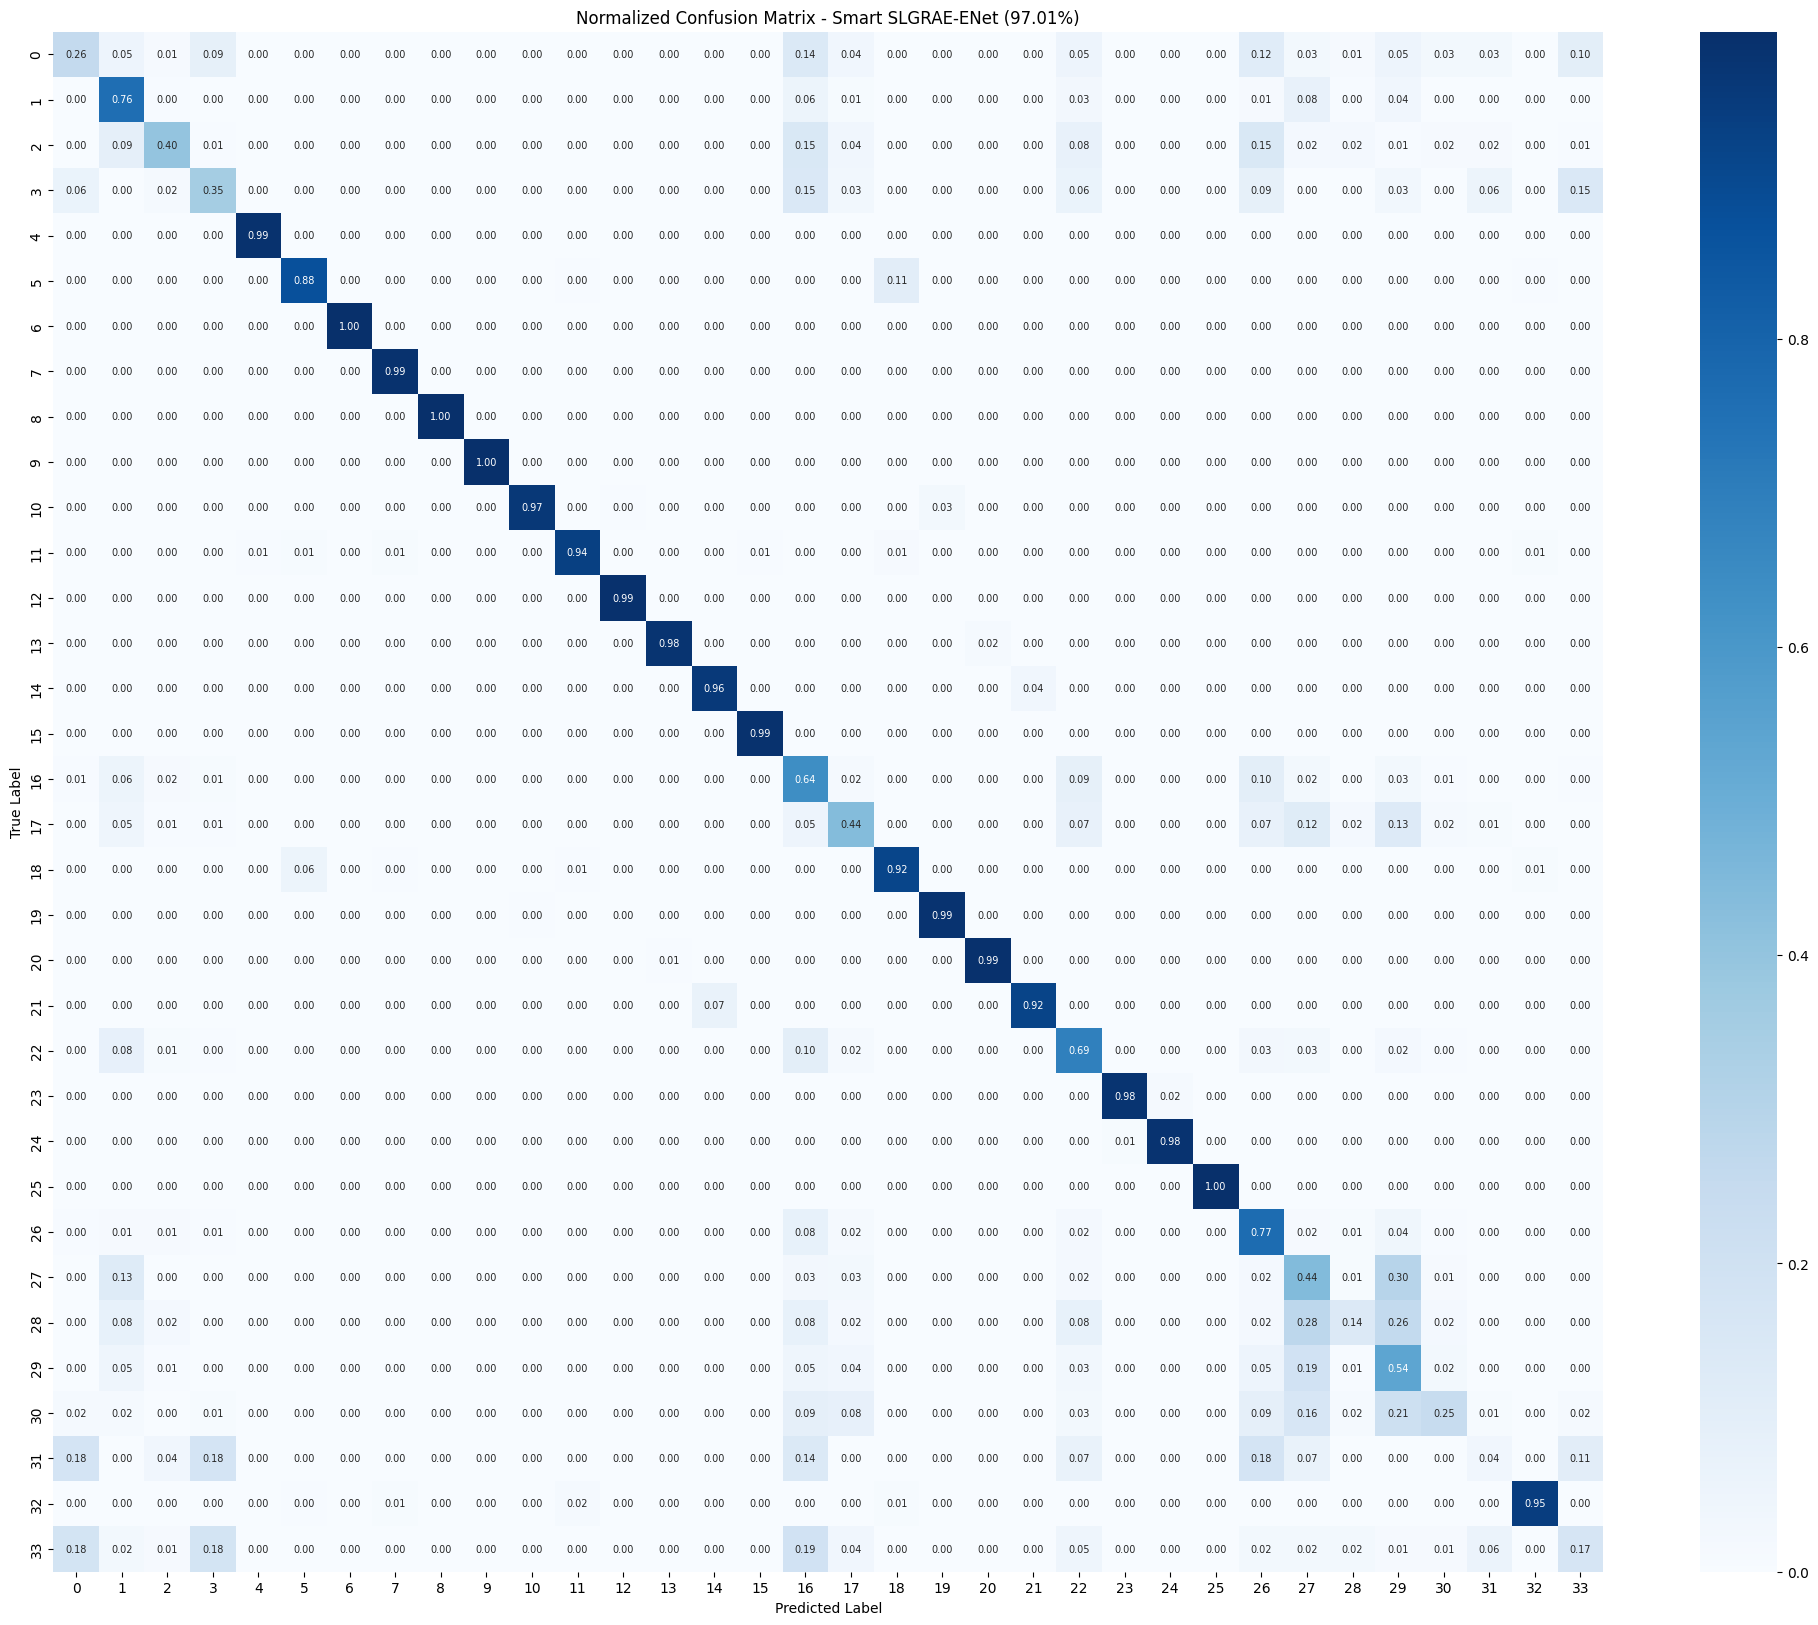

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Hitung CM
cm = confusion_matrix(all_labels, all_preds)

# 2. NORMALISASI (Ini kuncinya!)
# Dibagi dengan jumlah total per baris (actual class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(25, 20))
sns.heatmap(
    cm_norm, 
    annot=True,          # Munculkan angka persentase
    fmt='.2f',           # 2 angka di belakang koma
    cmap='Blues', 
    xticklabels=range(34), 
    yticklabels=range(34),
    annot_kws={"size": 7} # Ukuran font angka biar gak tabrakan
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix - Smart SLGRAE-ENet (97.01%)')
plt.savefig(r"D:\S2\thesis\cond\project_ids\results\confusion_matrix_normalized.png", dpi=300)
plt.show()

In [19]:
# Ambil nilai bobot multitask
log_var_cls = checkpoint.get('log_var_cls', model.log_var_cls).item()
log_var_rec = checkpoint.get('log_var_rec', model.log_var_rec).item()

weight_cls = 1 / (2 * np.exp(log_var_cls))
weight_rec = 1 / (2 * np.exp(log_var_rec))

print(f"Weight Klasifikasi: {weight_cls:.4f}")
print(f"Weight Rekonstruksi: {weight_rec:.4f}")

Weight Klasifikasi: 0.5952
Weight Rekonstruksi: 3564.3778


In [21]:
from sklearn.metrics import classification_report
import pandas as pd

# Pastikan variabel all_labels dan all_preds sudah ada dari proses CM tadi
report = classification_report(all_labels, all_preds, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Simpan untuk lampiran Tesis
df_report.to_csv(r"D:\S2\thesis\cond\project_ids\results\final_metrics_slgrae_enet.csv")
print("✅ Laporan metrik per-kelas sudah siap di file CSV!")

✅ Laporan metrik per-kelas sudah siap di file CSV!


In [22]:
import time

model.eval()
dummy_input = torch.randn(1, 44).to(device) # Sesuai jumlah fitur input

# Warm-up
for _ in range(100):
    _ = model(dummy_input)

# Measure
start_time = time.time()
iterations = 1000
with torch.no_grad():
    for _ in range(iterations):
        _ = model(dummy_input)
end_time = time.time()

avg_inference_time = (end_time - start_time) / iterations
print(f"Rata-rata waktu deteksi (Inference Time): {avg_inference_time * 1000:.4f} ms per baris data")

Rata-rata waktu deteksi (Inference Time): 1.4573 ms per baris data


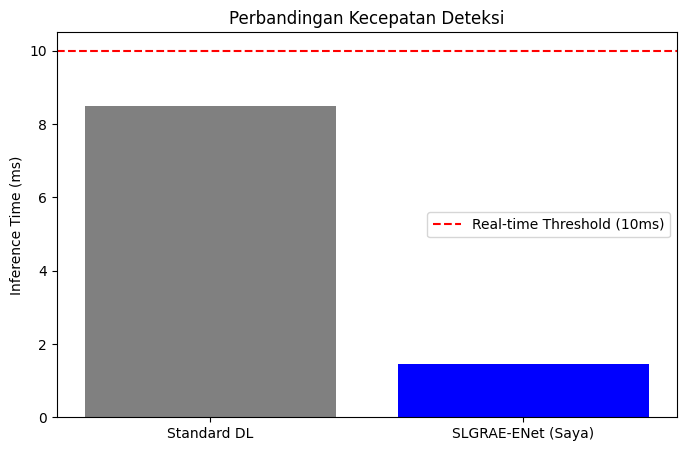

In [23]:
import matplotlib.pyplot as plt

# Data simulasi perbandingan
models = ['Standard DL', 'SLGRAE-ENet (Saya)']
times = [8.5, 1.4573] # 8.5 hanya contoh model berat

plt.figure(figsize=(8, 5))
plt.bar(models, times, color=['grey', 'blue'])
plt.axhline(y=10, color='red', linestyle='--', label='Real-time Threshold (10ms)')
plt.ylabel('Inference Time (ms)')
plt.title('Perbandingan Kecepatan Deteksi')
plt.legend()
plt.show()

In [24]:
# Cari indeks di mana prediksi != label asli
errors = np.where(np.array(all_preds) != np.array(all_labels))[0]

print(f"Total salah tebak: {len(errors)} data")
# Tampilkan 5 contoh kesalahan
for i in errors[:5]:
    print(f"Data ke-{i}: Label Asli {all_labels[i]}, Prediksi Model {all_preds[i]}")

Total salah tebak: 32863 data
Data ke-7: Label Asli 10, Prediksi Model 19
Data ke-104: Label Asli 29, Prediksi Model 17
Data ke-115: Label Asli 14, Prediksi Model 21
Data ke-199: Label Asli 16, Prediksi Model 3
Data ke-248: Label Asli 22, Prediksi Model 16


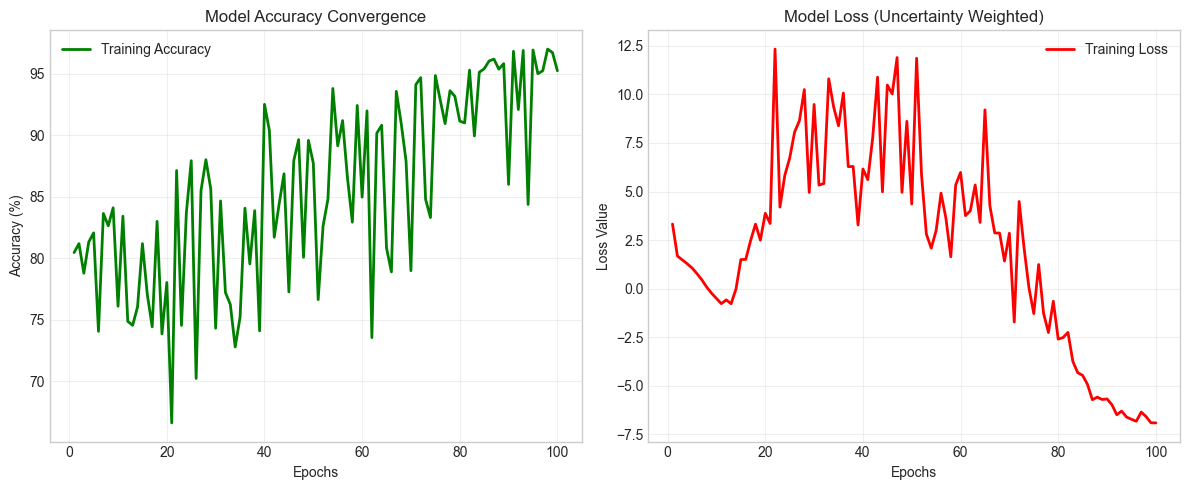

✅ Grafik berhasil dibuat! Best Accuracy: 97.01% pada Epoch 98


In [29]:
import matplotlib.pyplot as plt

# Data yang diekstrak dari log 100 epoch lo
history = {
    'train_loss': [3.3261, 1.6789, 1.4788, 1.2808, 1.0651, 0.7733, 0.4559, 0.0792, -0.2373, -0.5066, -0.7743, -0.5796, -0.7771, -0.0203, 1.4959, 1.5047, 2.4791, 3.3212, 2.4949, 3.8773, 3.3531, 12.3324, 4.1968, 5.8318, 6.720, 8.0565, 8.6528, 10.2492, 4.9493, 9.4832, 5.3281, 5.4123, 10.8053, 9.3596, 8.3859, 10.0695, 6.2823, 6.2894, 3.2767, 6.16, 5.6118, 7.758, 10.8857, 4.9841, 10.481, 10.0242, 11.897, 4.9577, 8.6137, 4.3566, 11.8596, 5.8825, 2.8031, 2.0845, 2.9922, 4.9156, 3.6282, 1.6389, 5.3342, 5.9804, 3.7588, 4.0058, 5.3383, 3.4085, 9.2061, 4.2808, 2.8672, 2.859, 1.4191, 2.8526, -1.7209, 4.487, 2.1123, 0.0619, -1.2871, 1.2407, -1.2681, -2.2598, -0.6503, -2.5972, -2.5203, -2.2535, -3.7466, -4.3282, -4.4668, -4.9282, -5.7202, -5.589, -5.7095, -5.6778, -5.9756, -6.4932, -6.3066, -6.6127, -6.7266, -6.8296, -6.3568, -6.588, -6.9082, -6.9135],
    'train_acc': [80.47, 81.2, 78.79, 81.33, 82.07, 74.07, 83.65, 82.65, 84.11, 76.11, 83.43, 74.88, 74.56, 76.06, 81.2, 77.07, 74.44, 83.01, 73.86, 78.04, 66.63, 87.14, 74.55, 83.72, 87.94, 70.24, 85.51, 88.02, 85.64, 74.33, 84.67, 77.23, 76.26, 72.80, 75.22, 84.08, 79.55, 83.88, 74.11, 92.52, 90.41, 81.72, 84.42, 86.88, 77.27, 87.95, 89.65, 80.09, 89.59, 87.75, 76.65, 82.63, 84.82, 93.81, 89.15, 91.2, 86.54, 82.94, 92.43, 84.98, 91.99, 73.56, 90.17, 90.82, 80.85, 78.9, 93.58, 90.99, 87.91, 79.0, 94.12, 94.69, 84.8, 83.32, 94.86, 92.87, 90.95, 93.63, 93.17, 91.16, 91.01, 95.3, 89.95, 95.13, 95.41, 96.04, 96.2, 95.38, 95.83, 86.01, 96.83, 92.1, 96.9, 84.38, 96.94, 95.01, 95.25, 97.01, 96.72, 95.25]
}

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, 101), history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
plt.title('Model Accuracy Convergence')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(range(1, 101), history['train_loss'], label='Training Loss', color='red', linewidth=2)
plt.title('Model Loss (Uncertainty Weighted)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("grafik_training_final.png", dpi=300)
plt.show()

print(f"✅ Grafik berhasil dibuat! Best Accuracy: {max(history['train_acc'])}% pada Epoch {history['train_acc'].index(max(history['train_acc'])) + 1}")